In [25]:
!pip install pandas seaborn --quiet

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [27]:
data = pd.read_csv("./dados_de_persistencia/roteador/data.csv")

In [28]:
data.head()

,Timestamp,IP_Origem,IP_Destino,Protocolo,Tamanho_Bytes,Status,Motivo
0,2026-04-14 20:15:24,10.0.2.103,10.0.1.2,TCP,54,BLOQUEADO,NULL Scan
1,2026-04-14 20:15:24,10.0.2.103,10.0.1.2,TCP,54,BLOQUEADO,NULL Scan
2,2026-04-14 20:15:24,10.0.2.103,10.0.1.2,TCP,54,BLOQUEADO,NULL Scan
3,2026-04-14 20:15:24,10.0.2.103,10.0.1.2,TCP,54,BLOQUEADO,NULL Scan
4,2026-04-14 20:15:24,10.0.2.103,10.0.1.2,TCP,54,BLOQUEADO,NULL Scan


In [29]:
import pandas as pd
import numpy as np

# Carrega os dados brutos salvos pelo roteador
df_raw = pd.read_csv("./dados_de_persistencia/roteador/data.csv")
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])

# 1. Identificar o "Ator" (Origem do tráfego)
def get_ator(ip):
    if ip == '10.0.1.2': return 'server'
    elif ip == '10.0.2.2': return 'client'
    else: return 'badguy'

df_raw['ator'] = df_raw['IP_Origem'].apply(get_ator)

# 2. Identificar o "Serviço"
def get_servico(row):
    if row['Status'] == 'BLOQUEADO':
        return row['Motivo'].replace(" ", "").lower() # Ex: 'nullscan'
    else:
        # Como o CSV não salvou a porta, inferimos o serviço legítimo pelo tamanho do pacote
        if row['Tamanho_Bytes'] < 75: return 'telnet'
        elif row['Tamanho_Bytes'] < 150: return 'http'
        else: return 'mariadb'

df_raw['servico'] = df_raw.apply(get_servico, axis=1)

# 3. Montar o "flow_id" no formato que o professor exige (ex: client-http, server-mariadb)
df_raw['flow_id'] = df_raw['ator'] + "-" + df_raw['servico']

# 4. Agrupar os pacotes para calcular os totais do fluxo
grouped = df_raw.groupby('flow_id').agg(
    total_bytes=('Tamanho_Bytes', 'sum'),
    total_packages=('Tamanho_Bytes', 'count'),
    time_min=('Timestamp', 'min'),
    time_max=('Timestamp', 'max')
).reset_index()

# 5. Calcular tempo, BPS e PPS
grouped['time_sec'] = (grouped['time_max'] - grouped['time_min']).dt.total_seconds()
grouped['time_sec'] = grouped['time_sec'].apply(lambda x: x if x > 0 else 1) # Evita divisão por zero

grouped['bps'] = grouped['total_bytes'] / grouped['time_sec']
grouped['pps'] = grouped['total_packages'] / grouped['time_sec']

# 6. O dataframe final com o nome 'data', contendo EXATAMENTE as colunas do professor
data = grouped[['flow_id', 'total_bytes', 'total_packages', 'time_sec', 'bps', 'pps']].copy()

print("✅ Dados preparados com sucesso! A tabela ficou assim:")
display(data)

✅ Dados preparados com sucesso! A tabela ficou assim:


,flow_id,total_bytes,total_packages,time_sec,bps,pps
0,badguy-nullscan,79920,1480,148.0,540.000000,10.000000
1,badguy-telnet,397514,5375,247.0,1609.368421,21.761134
2,client-http,70572,674,386.0,182.829016,1.746114
3,client-mariadb,37730,170,396.0,95.277778,0.429293
4,client-telnet,78531,1163,396.0,198.310606,2.936869
5,server-http,12314,147,398.0,30.939698,0.369347
6,server-mariadb,255237,771,393.0,649.458015,1.961832
7,server-telnet,274498,4883,398.0,689.693467,12.268844


/tmp/ipykernel_122756/3964441026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='flow_id', y='bps', palette='tab10')


Text(0, 0.5, 'BPS')

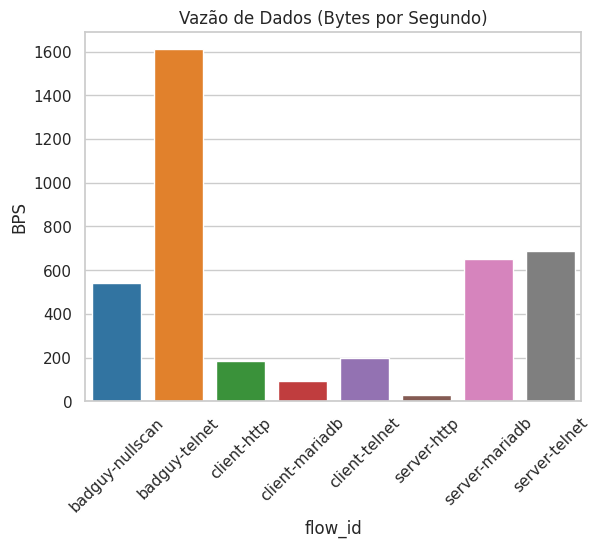

In [30]:
# --- GRÁFICO 1: Vazão por Serviço (BPS) ---
sns.barplot(data=data, x='flow_id', y='bps', palette='tab10')
plt.title('Vazão de Dados (Bytes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('BPS')

/tmp/ipykernel_122756/3351346017.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='flow_id', y='pps', palette='tab10')


Text(0, 0.5, 'PPS')

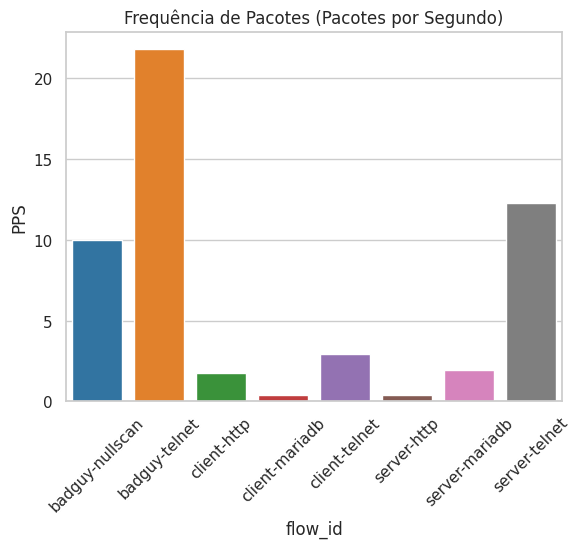

In [31]:
sns.barplot(data=data, x='flow_id', y='pps', palette='tab10')
plt.title('Frequência de Pacotes (Pacotes por Segundo)')
plt.xticks(rotation=45)
plt.ylabel('PPS')

In [32]:
data

,flow_id,total_bytes,total_packages,time_sec,bps,pps
0,badguy-nullscan,79920,1480,148.0,540.000000,10.000000
1,badguy-telnet,397514,5375,247.0,1609.368421,21.761134
2,client-http,70572,674,386.0,182.829016,1.746114
3,client-mariadb,37730,170,396.0,95.277778,0.429293
4,client-telnet,78531,1163,396.0,198.310606,2.936869
5,server-http,12314,147,398.0,30.939698,0.369347
6,server-mariadb,255237,771,393.0,649.458015,1.961832
7,server-telnet,274498,4883,398.0,689.693467,12.268844


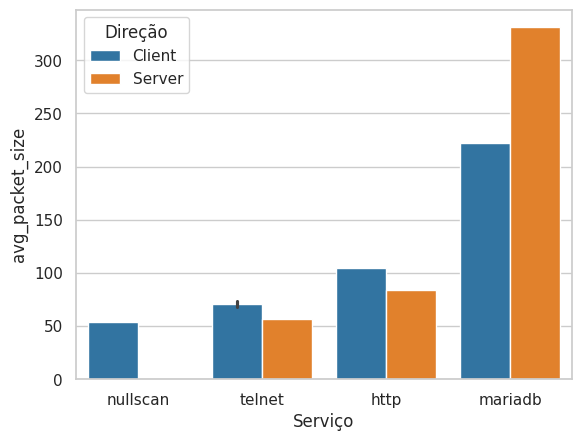

In [33]:
# Criar colunas extras para facilitar a plotagem
data = data.dropna()
data['Direção'] = data['flow_id'].apply(lambda x: 'Server' if 'server' in x else 'Client')
data['Serviço'] = data['flow_id'].apply(lambda x: x.split('-')[1])
data['avg_packet_size'] = data['total_bytes'] / data['total_packages']
# Usando Barplot para comparar o tamanho médio
ax = sns.barplot(data=data, x='Serviço', y='avg_packet_size', hue='Direção', palette='tab10')

Text(0.5, 1.0, 'Relação: Volume de Pacotes vs Volume de Bytes')

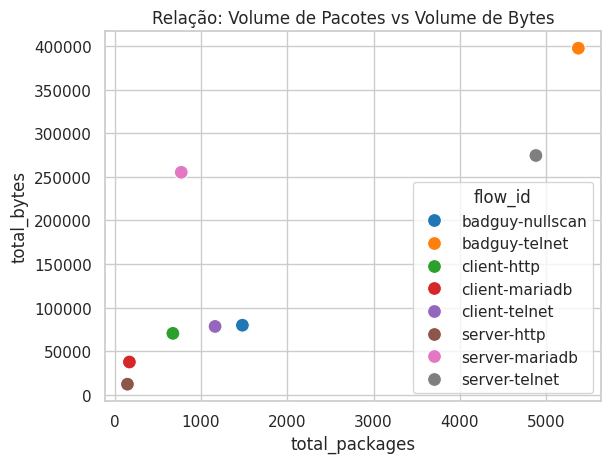

In [34]:
sns.scatterplot(data=data, x='total_packages', y='total_bytes', hue='flow_id', s=100, palette='tab10')
plt.title('Relação: Volume de Pacotes vs Volume de Bytes')

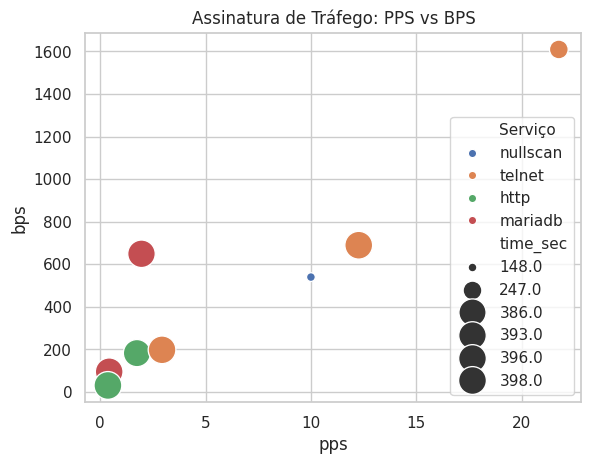

In [35]:
sns.scatterplot(data=data, x='pps', y='bps', hue='Serviço', size='time_sec', sizes=(40, 400))
plt.title("Assinatura de Tráfego: PPS vs BPS")
plt.show()